![jupyter](img/logo-itq.png)

# RED NEURONAL: MNIST DATASET  
## PAO26-27 - Python 01

![jupyter](img/logo-py.png)

**Nombre:** *David Ruiz*
RED NEURONAL: MNIST DATASET 

## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [1]:
# Forma dinamica de instalar paquetes
# !pip install $packageName
! pip install tensorflow

In [2]:
!pip freeze

absl-py==2.4.0
anyio @ file:///C:/miniconda3/conda-bld/anyio_1758622433823/work
argon2-cffi @ file:///C:/Users/task_176606717499708/croot/argon2-cffi_1766067891508/work
argon2-cffi-bindings @ file:///C:/miniconda3/conda-bld/argon2-cffi-bindings_1757925023673/work
asttokens @ file:///C:/b/abs_9662ywy9fp/croot/asttokens_1743630464377/work
astunparse==1.6.3
async-lru @ file:///C:/miniconda3/conda-bld/async-lru_1761121577604/work
attrs @ file:///C:/miniconda3/conda-bld/attrs_1762356899359/work
babel @ file:///C:/miniconda3/conda-bld/babel_1764159345001/work
beautifulsoup4 @ file:///C:/miniconda3/conda-bld/beautifulsoup4-split_1764159468811/work
bleach @ file:///C:/miniconda3/conda-bld/bleach_1764153675285/work
brotlicffi @ file:///C:/miniconda3/conda-bld/brotlicffi_1764961374486/work
certifi @ file:///C:/Users/task_176765924055489/croot/certifi_1767659363027/work/certifi
cffi @ file:///C:/miniconda3/conda-bld/cffi_1761832792955/work
charset-normalizer @ file:///C:/miniconda3/conda-bld/char

Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [3]:
!nvidia-smi

Fri Apr 10 14:36:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050      WDDM  |   00000000:01:00.0  On |                  N/A |
| 36%   32C    P8              6W /   70W |    1196MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

#### **- Cargando el conjunto de datos**

In [5]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

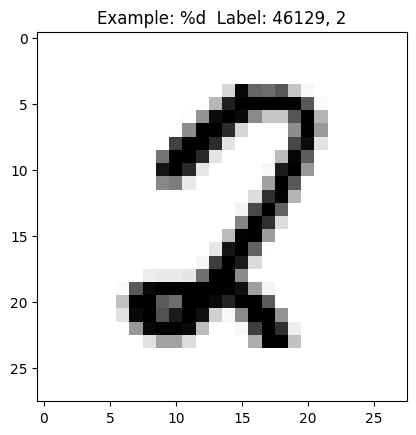

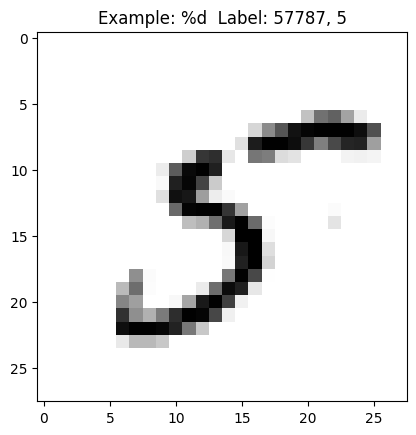

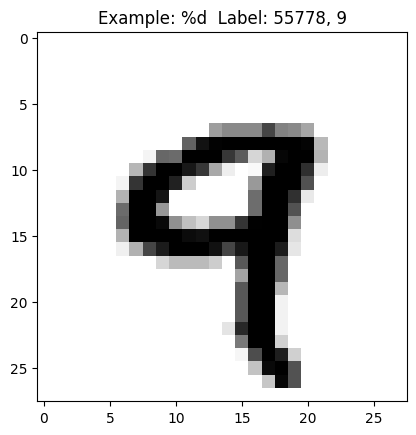

In [6]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [7]:
np.random.randint(0, x_train.shape[0])

50010

#### **- Acondicionando el conjunto de datos**

In [8]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [9]:
print(y_tr[25050])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [10]:
print(y_tr[25050].argmax(axis=0))

6


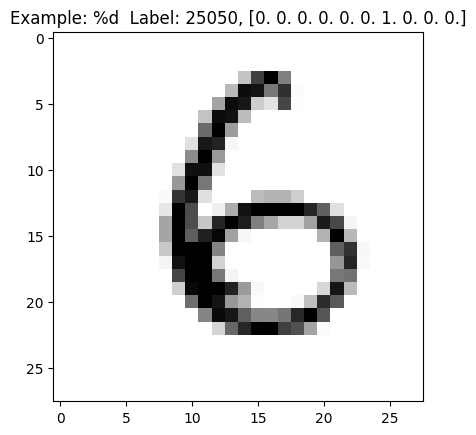

In [11]:
display_digit(25050, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [12]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
# Vamos a codificar la topología de nuestra primera red neuronal!!!
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(512, input_shape=(28*28,), activation="relu"))
model.add(Dense(10, activation="softmax")) #Capa salida -> Mismo número de neuronas que de clases objetivo

# Ahí tenemos nuestro primer MLP con una única capa oculta de 512 neuronas

E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [14]:
######### Modelo funcional ############ (Clase 04/10/2023)
# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x= Dropout(0.5)(x) Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

In [15]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)

[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9215 - loss: 0.2782 - val_accuracy: 0.9627 - val_loss: 0.1375
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9665 - loss: 0.1163 - val_accuracy: 0.9752 - val_loss: 0.0971
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0743 - val_accuracy: 0.9787 - val_loss: 0.0747
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9850 - loss: 0.0531 - val_accuracy: 0.9792 - val_loss: 0.0696
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0393 - val_accuracy: 0.9807 - val_loss: 0.0675
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9921 - loss: 0.0294 - val_accuracy: 0.9832 - val_loss: 0.0596
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9936 - loss: 0.0238 - val_accuracy: 0.9828 - val_loss: 0.0561
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.996

#### **- Observando el proceso de entrenamiento para tomar decisiones**

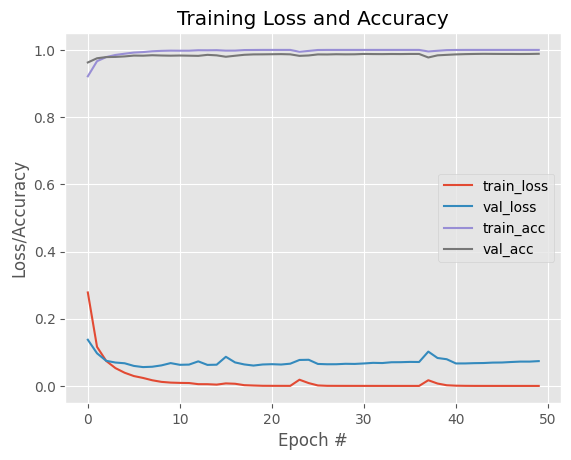

In [17]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [18]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[3.2696425e-16 2.3983147e-17 3.1525421e-14 8.6669255e-10 5.8727849e-22
 1.1865094e-17 9.4733359e-24 1.0000000e+00 6.7149643e-16 5.1554789e-12]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     

In [19]:
predictions[0].argmax(axis=0)

np.int64(7)

In [20]:
y_te[0].argmax(axis=0)

np.int64(7)

In [21]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

None


--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [28]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


E:\anaconda\envs\Deber1_machine\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [29]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [30]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [31]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [32]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [33]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [34]:
print(y_test[3])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [37]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6770 - loss: 1.4936 - val_accuracy: 0.7741 - val_loss: 1.0063
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8742 - loss: 0.5822 - val_accuracy: 0.8091 - val_loss: 0.8790
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9410 - loss: 0.2739 - val_accuracy: 0.7952 - val_loss: 0.9048
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9521 - loss: 0.1991 - val_accuracy: 0.7958 - val_loss: 0.9297
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9574 - loss: 0.1617 - val_accuracy: 0.7952 - val_loss: 0.9535
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9581 - loss: 0.1437 - val_accuracy: 0.7941 - val_loss: 0.9645
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9571 - loss: 0.1347 - val_accuracy: 0.7997 - val_loss: 0.9770
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9608 - loss: 0.1181 - val_accuracy: 0.

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,874,124 (14.78 MB)

 Trainable params: 1,291,374 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,582,750 (9.85 MB)

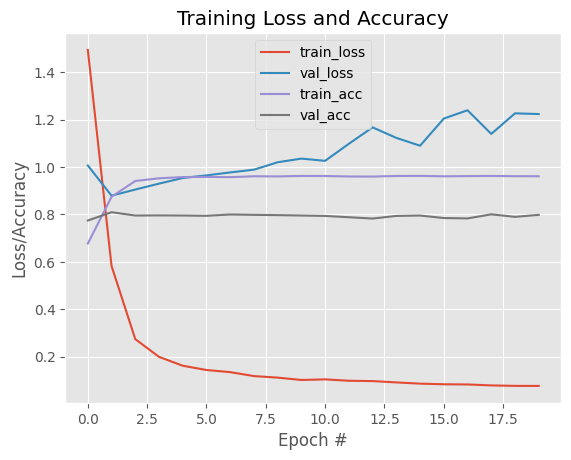

In [39]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [40]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7930 - loss: 1.3143
Loss 1.3142962455749512, accuracy 0.792965292930603


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [43]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6489 - loss: 2.4159 - val_accuracy: 0.7212 - val_loss: 1.8179
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7395 - loss: 1.7082 - val_accuracy: 0.7318 - val_loss: 1.7243
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7562 - loss: 1.6007 - val_accuracy: 0.7412 - val_loss: 1.6266
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7621 - loss: 1.5445 - val_accuracy: 0.7579 - val_loss: 1.6005
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7770 - loss: 1.5018 - val_accuracy: 0.7524 - val_loss: 1.6140
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7840 - loss: 1.4726 - val_accuracy: 0.7579 - val_loss: 1.5696
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7886 - loss: 1.4327 - val_accuracy: 0.7752 - val_loss: 1.5343
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7951 - loss: 1.4096 - val_accuracy:

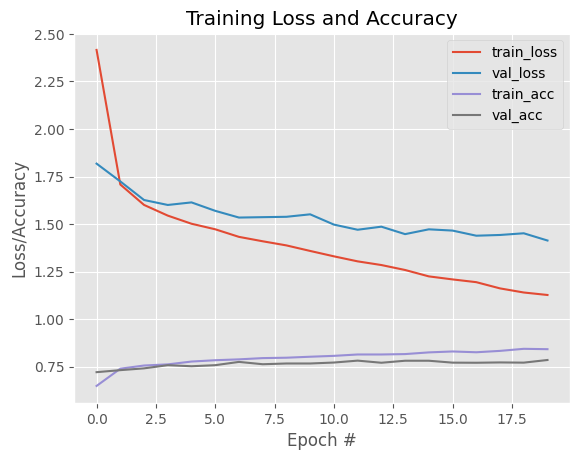

In [44]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [45]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7725 - loss: 1.4343
Loss 1.434300422668457, accuracy 0.7724844217300415


#### **- Dropout**

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [48]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5201 - loss: 2.0463 - val_accuracy: 0.6950 - val_loss: 1.3328
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6756 - loss: 1.3582 - val_accuracy: 0.7440 - val_loss: 1.1826
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7343 - loss: 1.1234 - val_accuracy: 0.7646 - val_loss: 1.0635
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7631 - loss: 0.9717 - val_accuracy: 0.7796 - val_loss: 1.0190
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7878 - loss: 0.8594 - val_accuracy: 0.7785 - val_loss: 1.0058
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8096 - loss: 0.7561 - val_accuracy: 0.7952 - val_loss: 1.0010
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8217 - loss: 0.6966 - val_accuracy: 0.7902 - val_loss: 1.0182
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8335 - loss: 0.6532 - val_accuracy: 0.

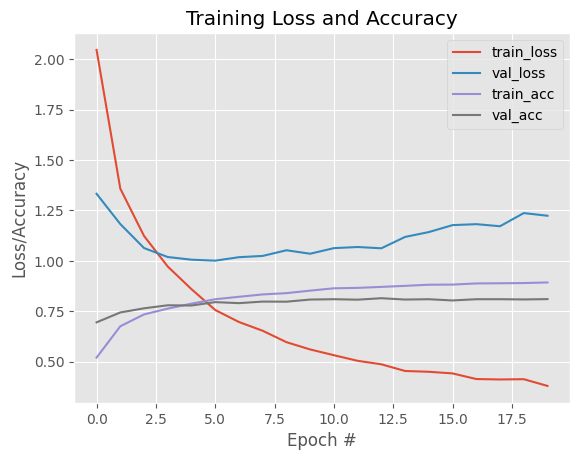

In [49]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [50]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7943 - loss: 1.3474
Loss 1.347357988357544, accuracy 0.7943009734153748


#### **- Batch Normalization**

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

E:\anaconda\envs\Deber1_machine\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [53]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4878 - loss: 2.4787 - val_accuracy: 0.6811 - val_loss: 1.7176
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6642 - loss: 1.5729 - val_accuracy: 0.7412 - val_loss: 1.2237
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7111 - loss: 1.3099 - val_accuracy: 0.7652 - val_loss: 1.1088
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7386 - loss: 1.1392 - val_accuracy: 0.7746 - val_loss: 1.0595
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7646 - loss: 1.0091 - val_accuracy: 0.7824 - val_loss: 1.0287
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7836 - loss: 0.9145 - val_accuracy: 0.7869 - val_loss: 1.0081
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7982 - loss: 0.8429 - val_accuracy: 0.7941 - val_loss: 0.9930
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8065 - loss: 0.7769 - val_accuracy: 0.

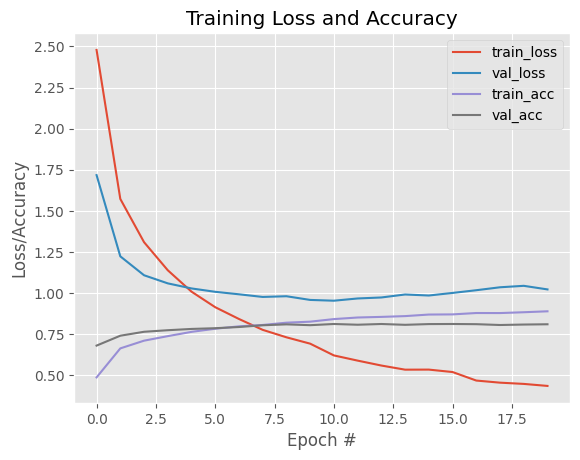

In [54]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [55]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8041 - loss: 1.1087
Loss 1.108713984489441, accuracy 0.8040961623191833


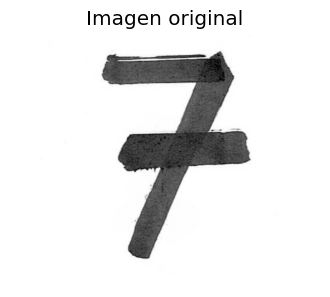

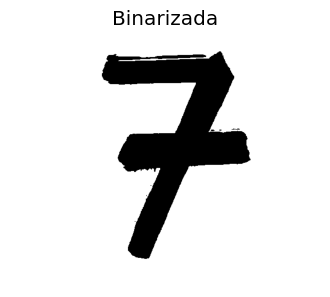

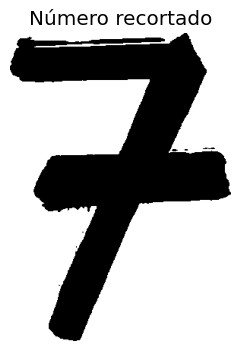

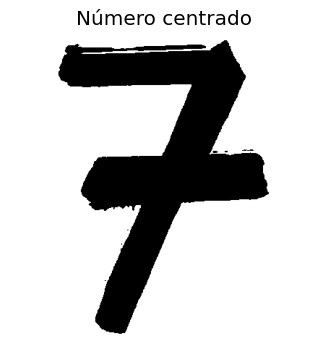

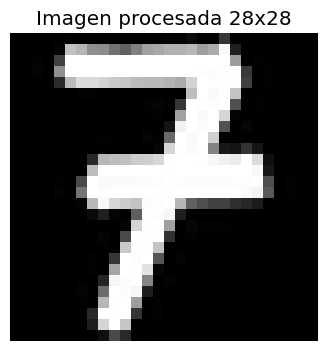

Shape final para predicción: (1, 28, 28)
Rango imagen: 0.0 1.0
Número predicho: 7
Probabilidades: [[0.000000e+00 0.000000e+00 5.994752e-18 5.902914e-26 0.000000e+00
  4.692288e-17 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00]]


In [26]:
from PIL import Image
# Nombre del archivo (ajústalo)
file_name = "images/Numero2.jpeg"

# 1) Abrir imagen en escala de grises
img = Image.open(file_name).convert("L")
img_array = np.array(img)

plt.figure(figsize=(4,4))
plt.imshow(img_array, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

# 2) Binarizar: número oscuro, fondo claro
bin_img = np.where(img_array < 180, 0, 255).astype(np.uint8)

plt.figure(figsize=(4,4))
plt.imshow(bin_img, cmap="gray")
plt.title("Binarizada")
plt.axis("off")
plt.show()

# 3) Recortar solo el número
coords = np.argwhere(bin_img == 0)
if len(coords) == 0:
    raise ValueError("No se detectó ningún número en la imagen.")

y0, x0 = coords.min(axis=0)
y1, x1 = coords.max(axis=0) + 1
digit = bin_img[y0:y1, x0:x1]

plt.figure(figsize=(4,4))
plt.imshow(digit, cmap="gray")
plt.title("Número recortado")
plt.axis("off")
plt.show()

# 4) Centrar en un lienzo cuadrado blanco
h, w = digit.shape
side = max(h, w) + 20
canvas = np.ones((side, side), dtype=np.uint8) * 255

y_offset = (side - h) // 2
x_offset = (side - w) // 2
canvas[y_offset:y_offset+h, x_offset:x_offset+w] = digit

plt.figure(figsize=(4,4))
plt.imshow(canvas, cmap="gray")
plt.title("Número centrado")
plt.axis("off")
plt.show()

# 5) Redimensionar a 28x28
img28 = Image.fromarray(canvas).resize((28, 28), Image.Resampling.LANCZOS)
img28 = np.array(img28).astype("float32") / 255.0

plt.figure(figsize=(4,4))
plt.imshow(img28, cmap="gray_r")
plt.title("Imagen procesada 28x28")
plt.axis("off")
plt.show()

# 6) Dar forma correcta al modelo
img_input = img28.reshape(1, 28, 28).astype("float32")

print("Shape final para predicción:", img_input.shape)
print("Rango imagen:", img_input.min(), img_input.max())

# 7) Predecir
pred = model.predict(img_input, verbose=0)
numero_predicho = np.argmax(pred)

print("Número predicho:", numero_predicho)
print("Probabilidades:", pred)

### Repositorio
* https://github.com/enderliliessad-pixel/Cuaderno_Machine2.git